# Project: High Dimensional Datascape

##### **Reference**: [Cosmic Black. (2024). High Dimensional Datascape [Data set]. Kaggle. https://www.kaggle.com/datasets/krishd123/high-dimensional-datascape](https://www.kaggle.com/datasets/krishd123/high-dimensional-datascape/data)

--- 
## **1. Look the big picture**

- **Objective**: Predict the binary class label (0 or 1) for each observation by selecting the best dimensionality reduction technique.
- **Goal**: Achieve the highest classification accuracy using dimensionality reduction methods.
- **Dimensional reduction techniques to explore**: 1. Manifold Learning techniques: Isomap, Locally Linear Embedding (LLE), MLE, Hessian LLE, MDS, t-SNE, UMAP 2. PCA: Singular Value Decomposition (SVD), Randomized PCA, Incremental PCA, kernel PCA. 3. Random Projection: Gaussian Random Projection, Sparse Random Projection. 4. Other Techniques: Linear Discriminant Analysis (LDA).
- **Evaluation Metric**: Accuracy, AUC-ROC & Time taken for training and prediction.

---
## **2. Get the data**

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/high_dimensional_datascape_proyect/all_data.csv"
)
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 527,Unnamed: 528,Unnamed: 529,Unnamed: 530,Unnamed: 531,Unnamed: 532,Unnamed: 533,Unnamed: 534,Unnamed: 535,Label
0,-0.000133,0.000262,0.001099,0.001834,0.002109,0.002223,0.002233,0.002036,0.001582,0.000969,...,0.82953,2.9079,3.7557,1.3344,0.74247,0.22507,0.56249,1.5705,0.79906,0
1,-0.000842,-0.001011,-0.001071,-0.000944,-0.000794,-0.000610,-0.000445,-0.000173,0.000077,0.000285,...,0.84335,3.0110,3.9877,1.2461,0.74423,0.22567,0.61034,1.6645,0.74574,0
2,-0.000766,-0.000535,0.000162,0.000898,0.001287,0.001582,0.001704,0.001659,0.001574,0.001438,...,0.87413,3.0613,3.9749,1.1560,0.52508,0.19934,0.45707,1.3386,0.74574,0
3,-0.000301,-0.000377,-0.000451,-0.000529,-0.000685,-0.000845,-0.000899,-0.000822,-0.000550,-0.000182,...,0.85467,3.3337,3.9205,1.3341,0.46024,0.20031,0.45924,1.7969,0.32451,0
4,-0.000589,-0.000857,-0.001135,-0.001171,-0.001128,-0.001039,-0.000959,-0.000937,-0.000916,-0.000819,...,0.82978,3.5814,3.7667,1.1151,0.44572,0.20538,0.41882,1.4422,0.32451,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,-0.000978,-0.001481,-0.002011,-0.001986,-0.001594,-0.001217,-0.000997,-0.000547,0.000031,0.000534,...,0.84507,3.0606,3.8405,1.3064,1.80800,0.72727,0.81104,2.5046,2.73800,1
226,-0.001599,-0.001084,0.000465,0.002076,0.002883,0.003667,0.004457,0.005221,0.005871,0.006257,...,0.84004,2.8913,3.7049,1.2511,1.41830,0.64878,0.82323,2.3979,2.35770,1
227,-0.000511,-0.001370,-0.002769,-0.003582,-0.003714,-0.003721,-0.003621,-0.003399,-0.003106,-0.002629,...,0.82726,3.2587,3.5905,1.2684,1.56390,0.66174,0.83218,2.4844,2.33220,1
228,-0.000880,-0.001734,-0.003095,-0.003891,-0.004015,-0.003949,-0.003827,-0.003839,-0.003775,-0.003182,...,0.84793,2.9933,3.9598,1.3825,1.59220,0.76657,0.80723,2.5448,2.67160,1


### Data augmentation (CTGAN)

In [2]:
# Validate if the aumented dataset is already created, if not,
# create it with the following code:
import os

path = "../data/high_dimensional_datascape_proyect/all_data_augmented.csv"
if os.path.exists(path):
    df = pd.read_csv(path)
    print("Augmented dataset loaded from:", path)
else:

    import torch
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    print("cuda version:", torch.version.cuda)
    print(
        "gpu:", torch.cuda.get_device_name(0)
        if torch.cuda.is_available() else "none"
    )

    from ctgan import CTGAN

    discrete_columns = ["Label"]

    for col in discrete_columns:
        df[col] = df[col].astype("category")

    ctgan = CTGAN(
        epochs=30,      # you can tune this
        batch_size=512,
        pac=1, 
        cuda=True
    )

    ctgan.fit(df, discrete_columns=discrete_columns)

    n_samples = 10_000
    synthetic = ctgan.sample(n_samples)

    print(synthetic.shape)  # should be (10000, df.shape[1])
    synthetic.head()

    df = pd.concat([df, synthetic], ignore_index=True)

    # Save new dataframe to csv
    df.to_csv(
        path,
        index=False
    )

Augmented dataset loaded from: ../data/high_dimensional_datascape_proyect/all_data_augmented.csv


In [3]:
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 527,Unnamed: 528,Unnamed: 529,Unnamed: 530,Unnamed: 531,Unnamed: 532,Unnamed: 533,Unnamed: 534,Unnamed: 535,Label
0,-0.000133,0.000262,0.001099,0.001834,0.002109,0.002223,0.002233,0.002036,0.001582,0.000969,...,0.829530,2.907900,3.755700,1.334400,0.742470,0.225070,0.562490,1.570500,0.799060,0
1,-0.000842,-0.001011,-0.001071,-0.000944,-0.000794,-0.000610,-0.000445,-0.000173,0.000077,0.000285,...,0.843350,3.011000,3.987700,1.246100,0.744230,0.225670,0.610340,1.664500,0.745740,0
2,-0.000766,-0.000535,0.000162,0.000898,0.001287,0.001582,0.001704,0.001659,0.001574,0.001438,...,0.874130,3.061300,3.974900,1.156000,0.525080,0.199340,0.457070,1.338600,0.745740,0
3,-0.000301,-0.000377,-0.000451,-0.000529,-0.000685,-0.000845,-0.000899,-0.000822,-0.000550,-0.000182,...,0.854670,3.333700,3.920500,1.334100,0.460240,0.200310,0.459240,1.796900,0.324510,0
4,-0.000589,-0.000857,-0.001135,-0.001171,-0.001128,-0.001039,-0.000959,-0.000937,-0.000916,-0.000819,...,0.829780,3.581400,3.766700,1.115100,0.445720,0.205380,0.418820,1.442200,0.324510,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10225,0.002965,0.001802,-0.003977,-0.006455,0.004782,0.014225,0.007910,0.002532,0.004905,0.001521,...,0.853818,2.996758,3.922966,0.957879,1.773485,0.687621,0.696808,2.630397,-0.262117,0
10226,0.001543,-0.003890,-0.001085,-0.007528,0.006979,0.005835,0.005124,0.001627,-0.006804,0.004568,...,0.839390,2.741789,3.676626,1.334166,0.582455,0.549024,0.854311,1.483370,2.367232,0
10227,0.000232,0.001155,-0.003710,-0.015075,0.005110,0.013539,0.000159,0.000950,-0.005521,0.004073,...,0.834463,3.282348,4.091521,1.254908,1.345841,0.633805,0.729958,1.184102,2.062843,1
10228,-0.000094,-0.003063,0.010718,-0.003929,0.018042,0.001714,0.001164,0.005746,0.004777,-0.000218,...,0.852616,2.434263,4.325216,0.929110,0.628725,0.755097,0.586806,2.153717,2.030267,1


---
## **3. Explore and visualize the data to gain insights.**

In [4]:
df["Label"].value_counts() / len(df)

Label
1    0.519062
0    0.480938
Name: count, dtype: float64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10230 entries, 0 to 10229
Columns: 537 entries, Unnamed: 0 to Label
dtypes: float64(536), int64(1)
memory usage: 41.9 MB


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10230.0,0.001141,0.002471,-0.005145,-0.000459,0.001017,0.002318,0.012025
Unnamed: 1,10230.0,-0.001080,0.002905,-0.006392,-0.003063,-0.001528,0.000255,0.013909
Unnamed: 2,10230.0,0.001815,0.004218,-0.008423,-0.000870,0.001345,0.003533,0.019127
Unnamed: 3,10230.0,-0.006645,0.003746,-0.015141,-0.009416,-0.007321,-0.004481,0.015377
Unnamed: 4,10230.0,0.006685,0.005369,-0.008909,0.003525,0.006086,0.008319,0.024174
...,...,...,...,...,...,...,...,...
Unnamed: 532,10230.0,0.553226,0.229406,-0.107795,0.382843,0.593505,0.736152,0.989682
Unnamed: 533,10230.0,0.742837,0.118665,0.228444,0.711562,0.765651,0.815334,1.122825
Unnamed: 534,10230.0,2.123960,0.475124,0.478956,1.847174,2.194158,2.459959,3.542448
Unnamed: 535,10230.0,1.810510,0.846107,-0.824468,1.479030,2.108883,2.353706,3.231113


In [7]:
# columns with null values
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [8]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import umap
from sklearn.decomposition import PCA
import os

X = df.drop('Label', axis=1)
y = df['Label']

# Paths for saved visualizations
umap_html_path = "../data/high_dimensional_datascape_proyect/umap_projection.html"
umap_json_path = "../data/high_dimensional_datascape_proyect/umap_projection.json"
pca_html_path = "../data/high_dimensional_datascape_proyect/pca_projection.html"
pca_json_path = "../data/high_dimensional_datascape_proyect/pca_projection.json"

# Check if visualizations already exist
if os.path.exists(umap_json_path) and os.path.exists(pca_json_path):
    print("Visualizations already exist. Loading saved figures...")
    print(f"UMAP: {umap_html_path}")
    print(f"PCA: {pca_html_path}")
    
    # Load and display the figures
    fig_umap = pio.read_json(umap_json_path)
    fig_umap.show()
    
    fig_pca = pio.read_json(pca_json_path)
    fig_pca.show()
else:
    print("Generating visualizations (this may take a while)...")
    
    # Standardize (crucial for these methods)
    from sklearn.preprocessing import StandardScaler
    
    X_scaled = StandardScaler().fit_transform(X)
    
    # UMAP (install umap-learn if needed)
    print("Running UMAP...")
    reducer_umap = umap.UMAP(n_components=2, random_state=42)
    embed_umap = reducer_umap.fit_transform(X_scaled)
    
    fig_umap = px.scatter(
        x=embed_umap[:,0], y=embed_umap[:,1], color=y.astype(str),
        title='UMAP Projection (High Dim Datascape)'
    )
    fig_umap.write_html(umap_html_path)
    fig_umap.write_json(umap_json_path)
    print(f"UMAP saved to {umap_html_path} and {umap_json_path}")
    fig_umap.show()
    
    # PCA
    print("Running PCA...")
    pca = PCA(n_components=2, random_state=42)
    embed_pca = pca.fit_transform(X_scaled)
    
    fig_pca = px.scatter(
        x=embed_pca[:,0], y=embed_pca[:,1], color=y.astype(str),
        title=f'PCA Projection (PC1: {pca.explained_variance_ratio_[0]:.1%} var)'
    )
    fig_pca.write_html(pca_html_path)
    fig_pca.write_json(pca_json_path)
    print(f"PCA saved to {pca_html_path} and {pca_json_path}")
    fig_pca.show()
    
    print("Visualizations complete and saved!")

c:\Users\david\Documents\Courses\MachineLearningPortfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Visualizations already exist. Loading saved figures...
UMAP: ../data/high_dimensional_datascape_proyect/umap_projection.html
PCA: ../data/high_dimensional_datascape_proyect/pca_projection.html


---
## **4. Prepare the data for machine learning algorithms.**

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(
    n_splits=1, test_size=0.3, random_state=42
)
X = df.drop(columns="Label")
y = df["Label"]
for train_idx, test_idx in strat_split.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [10]:
print(round(y_train.value_counts() / len(y_train), 2))
print(round(y_test.value_counts() / len(y_test), 2))

Label
1    0.52
0    0.48
Name: count, dtype: float64
Label
1    0.52
0    0.48
Name: count, dtype: float64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def get_pipeline(dimension_reduction_model=None):
    if dimension_reduction_model:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('dim_red', dimension_reduction_model),
            ('clf', LogisticRegression(random_state=42))
        ],
        verbose=True
        )
    else:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(random_state=42))
        ],
        verbose=True
        )

In [12]:
# Results funtion to read result json, see if the model is already evaluated,
# if not, evaluate it and save the results to a json file
import json
import os

RESULTS_PATH = "../data/high_dimensional_datascape_proyect/results.json"

def load_results():
    if not os.path.exists(RESULTS_PATH):
        return {}
    try:
        with open(RESULTS_PATH, "r") as f:
            content = f.read().strip()
            if not content:
                return {}
            return json.loads(content)
    except json.JSONDecodeError:
        # If the file is empty or corrupted, start fresh
        return {}

def should_evaluate(model_name):
    results = load_results()
    return model_name not in results

### Metric funtion

In [13]:
import json

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve


def save_results(model_name, acc, auc, fpr, tpr, thresholds, idx, total_time):
    results = load_results()
    results[model_name] = {
        "Accuracy": float(acc),
        "AUC": float(auc),
        "Time": float(total_time),
        "fpr": fpr.tolist(),
        "tpr": tpr.tolist(),
        "thresholds": thresholds.tolist(),
        "idx": int(idx)
    }
    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=4)


def evaluate_and_save_results(
        model_name, y_test, y_pred, y_score, total_time, target_threshold=0.5
):
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    idx = np.argmin(np.abs(thresholds - target_threshold))
    save_results(model_name, acc, auc, fpr, tpr, thresholds, idx, total_time)


def plot_model(model_name):
 
    # Load results
    results = load_results()
    acc = results[model_name]["Accuracy"]
    auc = results[model_name]["AUC"]
    total_time = results[model_name]["Time"]
    fpr = np.array(results[model_name]["fpr"])
    tpr = np.array(results[model_name]["tpr"])
    thresholds = np.array(results[model_name]["thresholds"])
    idx = results[model_name]["idx"]



    # Single figure with ROC curve and threshold 0.5 marked
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot ROC curve
    ax.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")

    # Mark the threshold ≈ 0.5 point (closest in thresholds array)
    thr, fpr_i, tpr_i = thresholds[idx], fpr[idx], tpr[idx]
    ax.scatter(
        fpr[idx], tpr[idx],
        color="red", s=100, zorder=5,
        label=f"Threshold ≈ {thr:.3f} (FPR={fpr_i:.3f}, TPR={tpr_i:.3f})"
    )

    # Dashed guides to axes
    ax.axvline(fpr[idx], linestyle="--", alpha=0.6, color="red")
    ax.axhline(tpr[idx], linestyle="--", alpha=0.6, color="red")

    # Random baseline
    ax.plot([0, 1], [0, 1], "k--", alpha=0.8, label="Random (AUC=0.5)")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    title = f"ROC Curve - {model_name} (Acc={acc:.3f}, AUC={auc:.3f}, Time={total_time:.1f}s)"
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5. Select a model, train & Fine-tune it

### Base model without dimensionality reduction

In [14]:
model_name = "No Dimensionality Reduction"

Results for 'No Dimensionality Reduction' already exist. Loading and plotting...


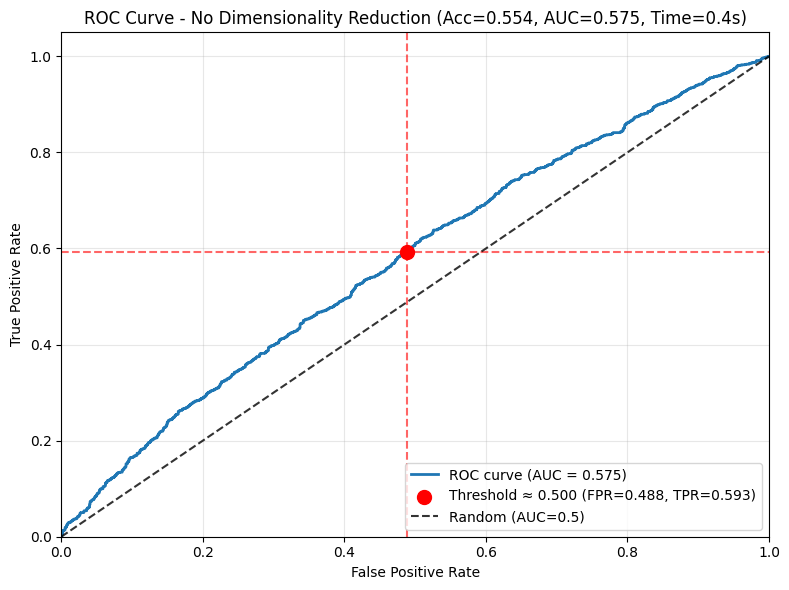

In [15]:

if should_evaluate(model_name):
    pipe = get_pipeline()
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:,1]
    evaluate_and_save_results(model_name, y_test, y_pred, y_score, 0.4)

else:
    print(f"Results for '{model_name}' already exist. Loading and plotting...")

plot_model(model_name)

### Isomap

Isomap is a nonlinear manifold learning method that preserves **geodesic (manifold) distances** by building a neighborhood graph and applying classical MDS to the shortest‐path distances. It is useful when the data lies on a curved, low‑dimensional manifold.

**Key parameters used below:**
- **`n_neighbors`**: number of nearest neighbors in the graph; controls how local the manifold approximation is (small = local detail, large = more global structure).
- **`n_components`**: target dimensionality of the embedding; chosen by validation to balance compression and classification performance.

The next cells tune these parameters with Bayesian search and then train the best Isomap pipeline.

In [16]:
model_name = "Isomap"

In [17]:
from sklearn.manifold import Isomap
from skopt import BayesSearchCV
from skopt.space import Integer

if should_evaluate(model_name):

    search_spaces = {
        'dim_red__n_neighbors': Integer(5, 30),
        'dim_red__n_components': Integer(2, 20)
    }

    opt = BayesSearchCV(
        get_pipeline(Isomap(n_jobs=-1)),
        search_spaces,
        n_iter=20,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    opt.fit(X_train, y_train)
    print("Best parameters:", opt.best_params_)
    print("Best AUC:", opt.best_score_)

    # Save parameters
    n_neighbors = opt.best_params_['dim_red__n_neighbors']
    n_components = opt.best_params_['dim_red__n_components']

Results for 'Isomap' already exist. Loading and plotting...


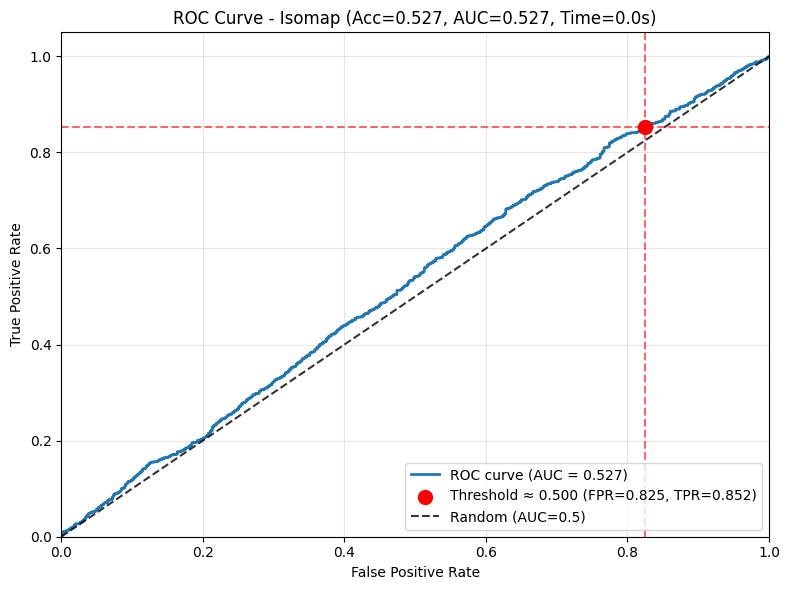

In [18]:

if should_evaluate(model_name):
    best_isomap = Isomap(
        n_neighbors=n_neighbors,
        n_components=n_components,
        n_jobs=-1
    )
    pipe_isomap = get_pipeline(best_isomap)
    pipe_isomap.fit(X_train, y_train)
    y_pred_isomap = pipe_isomap.predict(X_test)
    y_score_isomap = pipe_isomap.predict_proba(X_test)[:,1]
    evaluate_and_save_results(
        model_name, y_test, y_pred_isomap, y_score_isomap, 0.0
    )

else:
    print(f"Results for '{model_name}' already exist. Loading and plotting...")

plot_model(model_name)

### Locally Linear Embedding (LLE)

Locally Linear Embedding is a nonlinear manifold learning method that preserves **local linear structure** by reconstructing each point as a weighted combination of its neighbors, then finding a low‑dimensional embedding that best maintains those weights. It is useful when the data lies on a locally linear, curved manifold.

**Key parameters used below:**
- **`n_neighbors`**: number of nearest neighbors used for local reconstruction; controls the size of the local linear patch (small = fine local detail, large = smoother structure).
- **`n_components`**: target dimensionality of the embedding; chosen by validation to balance compression and classification performance.
- **`reg`**: regularization parameter to stabilize the weight matrix inversion; prevents ill‑conditioned solutions when neighbors are nearly collinear.

The next cells tune these parameters with Bayesian search and then train the best LLE pipeline.

In [19]:
model_name = "Locally Linear Embedding (LLE)"

In [20]:
from sklearn.manifold import LocallyLinearEmbedding
from skopt import BayesSearchCV
from skopt.space import Integer, Real

if should_evaluate(model_name):
    search_spaces = {
        'dim_red__n_neighbors': Integer(21, 60.
        
        ),  # raised floor
        'dim_red__n_components': Integer(2, 20),
        'dim_red__reg': Real(1e-4, 1e-1, prior='log-uniform')
    }

    opt = BayesSearchCV(
        get_pipeline(LocallyLinearEmbedding(
            n_jobs=-1, random_state=42)),
        search_spaces,
        n_iter=20,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    opt.fit(X_train, y_train)
    print("Best parameters:", opt.best_params_)
    print("Best AUC:", opt.best_score_)

    # Save parameters
    n_neighbors = opt.best_params_['dim_red__n_neighbors']
    n_components = opt.best_params_['dim_red__n_components']
    reg = opt.best_params_['dim_red__reg']
else:
    print("Best parameters: OrderedDict([('dim_red__n_components', 15),"
    "('dim_red__n_neighbors', 58), ('dim_red__reg', 0.0003096146742088961)])")
    print("Best AUC: 0.5274403016338501")

Best parameters: OrderedDict([('dim_red__n_components', 15),('dim_red__n_neighbors', 58), ('dim_red__reg', 0.0003096146742088961)])
Best AUC: 0.5274403016338501


Results for 'Locally Linear Embedding (LLE)' already exist. Loading and plotting...


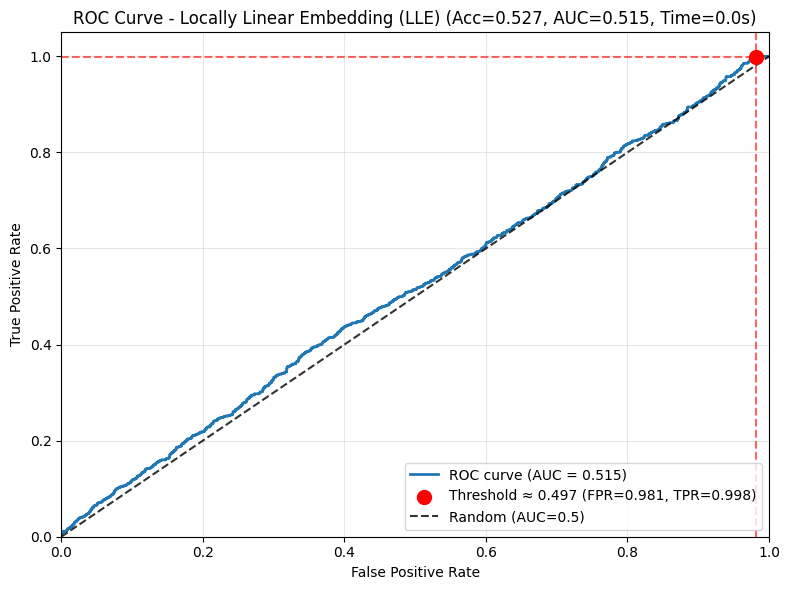

In [21]:
if should_evaluate(model_name):
    best_lle = LocallyLinearEmbedding(
        n_neighbors=n_neighbors,
        n_components=n_components,
        reg=reg,
        n_jobs=-1,
        random_state=42
    )
    pipe_lle = get_pipeline(best_lle)
    pipe_lle.fit(X_train, y_train)
    y_pred_lle = pipe_lle.predict(X_test)
    y_score_lle = pipe_lle.predict_proba(X_test)[:,1]
    evaluate_and_save_results(model_name, y_test, y_pred_lle, y_score_lle, 0.0)
else:
    print(f"Results for '{model_name}' already exist. Loading and plotting...")
plot_model(model_name)

###  Modified LLE (MLLE)

Modified Locally Linear Embedding (MLLE) is a variant of standard LLE that addresses regularization and ill‑conditioning issues by using **multiple weight vectors** derived from a nullspace‑based approach. It is useful when standard LLE suffers from degeneracies or when the local neighborhoods have insufficient rank.

**Key parameters used below:**
- **`n_neighbors`**: number of nearest neighbors used for local reconstruction; controls the size of the local linear patch (small = fine local detail, large = smoother structure).
- **`n_components`**: target dimensionality of the embedding; chosen by validation to balance compression and classification performance.
- **`reg`**: regularization parameter to stabilize the weight matrix inversion; prevents ill‑conditioned solutions when neighbors are nearly collinear.

The next cells tune these parameters with Bayesian search and then train the best MLLE pipeline.

In [22]:
model_name = "Modified LLE (MLLE)"

In [23]:
from sklearn.manifold import LocallyLinearEmbedding
from skopt import BayesSearchCV
from skopt.space import Integer, Real

if should_evaluate(model_name):
    search_spaces = {
        'dim_red__n_neighbors': Integer(21, 60),  # raised floor
        'dim_red__n_components': Integer(2, 20),
        'dim_red__reg': Real(1e-4, 1e-1, prior='log-uniform')
    }

    opt = BayesSearchCV(
        get_pipeline(LocallyLinearEmbedding(
            method='modified',
            n_jobs=-1, random_state=42
            )),
        search_spaces,
        n_iter=20,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    opt.fit(X_train, y_train)
    print("Best parameters:", opt.best_params_)
    print("Best AUC:", opt.best_score_)

    # Save parameters
    n_neighbors = opt.best_params_['dim_red__n_neighbors']
    n_components = opt.best_params_['dim_red__n_components']
    reg = opt.best_params_['dim_red__reg']
else:
    print("Best parameters: OrderedDict([('dim_red__n_components', 18),"
    "('dim_red__n_neighbors', 60), ('dim_red__reg', 0.0001)])")
    print("Best AUC: 0.5249266862170089")


Best parameters: OrderedDict([('dim_red__n_components', 18),('dim_red__n_neighbors', 60), ('dim_red__reg', 0.0001)])
Best AUC: 0.5249266862170089


Results for 'Modified LLE (MLLE)' already exist. Loading and plotting...


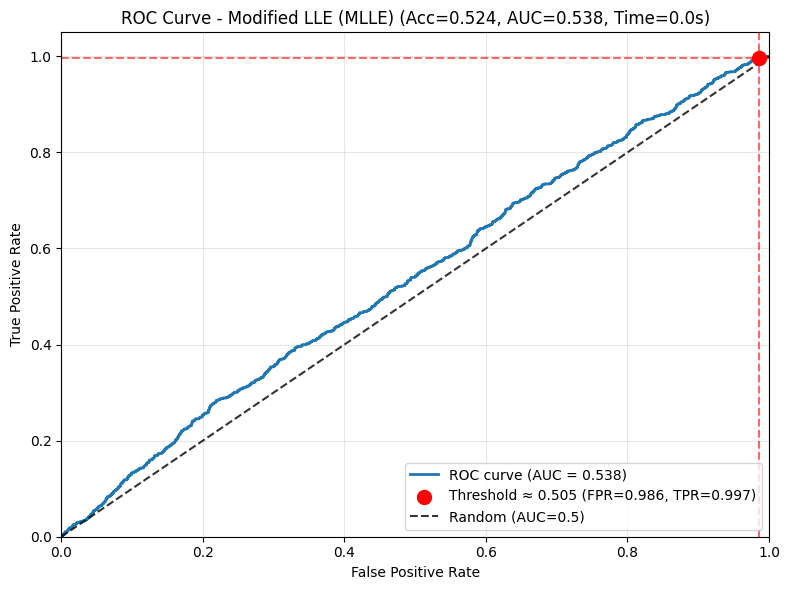

In [24]:
if should_evaluate(model_name):
    best_lle = LocallyLinearEmbedding(
        n_neighbors=n_neighbors,
        n_components=n_components,
        reg=reg,
        n_jobs=-1,
        random_state=42,
        method='modified'
    )
    pipe_lle = get_pipeline(best_lle)
    pipe_lle.fit(X_train, y_train)
    y_pred_lle = pipe_lle.predict(X_test)
    y_score_lle = pipe_lle.predict_proba(X_test)[:,1]
    evaluate_and_save_results(model_name, y_test, y_pred_lle, y_score_lle, 0.0)
else:
    print(f"Results for '{model_name}' already exist. Loading and plotting...")
plot_model(model_name)

### Hessian LLE

In [25]:
model_name = "Hessian LLE"

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding
from skopt import BayesSearchCV
from skopt.space import Integer, Real

if should_evaluate(model_name):
    # Hessian LLE requires: n_neighbors > n_components * (n_components + 3) / 2
    # For n_components=6 (max): need n_neighbors > 27 → floor set to 28
    # This guarantees ALL combinations in the search space are valid.
    search_spaces = {
        'dim_red__n_neighbors': Integer(28, 60),
        'dim_red__n_components': Integer(2, 6),
        'dim_red__reg': Real(1e-4, 1e-1, prior='log-uniform')
    }

    opt = BayesSearchCV(
        get_pipeline(LocallyLinearEmbedding(
            method='hessian',
            eigen_solver='dense',  # to avoid convergence issues with sparse solver
            n_jobs=-1, random_state=42
            )),
        search_spaces,
        n_iter=20,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    opt.fit(X_train, y_train)
    print("Best parameters:", opt.best_params_)
    print("Best AUC:", opt.best_score_)

    # Save parameters
    n_neighbors = opt.best_params_['dim_red__n_neighbors']
    n_components = opt.best_params_['dim_red__n_components']
    reg = opt.best_params_['dim_red__reg']
else:
    print("Best parameters: OrderedDict([('dim_red__n_components', 4),"
        "('dim_red__n_neighbors', 51), ('dim_red__reg', 0.06289324408100383)])" \
        "Best AUC: 0.5190615835777126"
    )


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

[Pipeline] ............ (step 1 of 3) Processing scaler, total=   0.1s
[Pipeline] ........... (step 2 of 3) Processing dim_red, total= 2.1min
[Pipeline] ............... (step 3 of 3) Processing clf, total=   0.0s


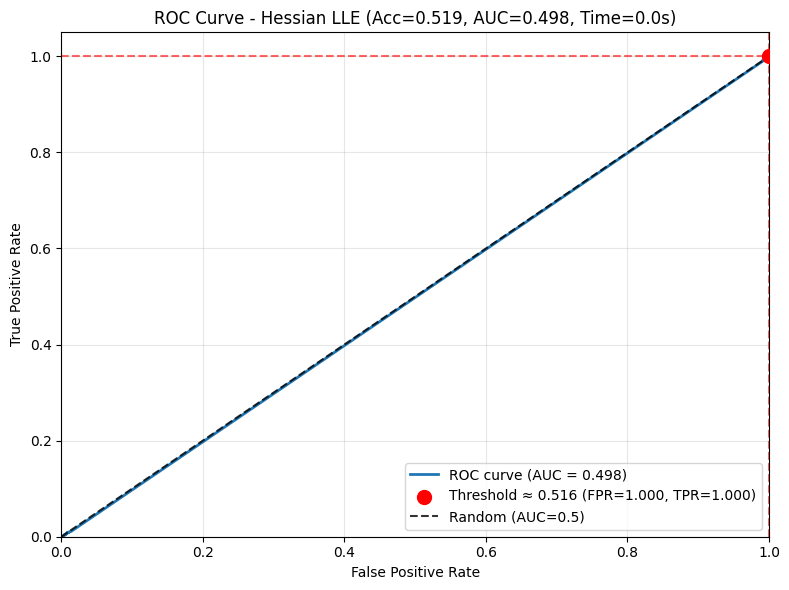

In [27]:
if should_evaluate(model_name):
    best_lle = LocallyLinearEmbedding(
        method='hessian',
        eigen_solver='dense',
        n_neighbors=n_neighbors,
        n_components=n_components,
        reg=reg,
        n_jobs=-1,
        random_state=42
    )
    pipe_lle = get_pipeline(best_lle)
    pipe_lle.fit(X_train, y_train)
    y_pred_lle = pipe_lle.predict(X_test)
    y_score_lle = pipe_lle.predict_proba(X_test)[:,1]
    evaluate_and_save_results(model_name, y_test, y_pred_lle, y_score_lle, 0.0)
else:
    print(f"Results for '{model_name}' already exist. Loading and plotting...")
plot_model(model_name)